# A Data Driven Analysis of Global Shipping Emissions - Methodology

A two-vessel replication of Selin et al. (2021), *Mitigation of CO₂ emissions frominternational shipping through national allocation* (Environ. Res. Lett. 16, 045009), built entirely from public data.

This notebook walks through `docs/METHODOLOGY.md` section by section, Section 0 to Section 8. It demonstrates the pipeline; it does not reimplement it. Every computation calls into `src/emissions_allocation/`, and every physical formula is cited to its source inline.

## How to read the numbers

Two of the parameters this model needs : installed power and design speed : cannot be observed from any free source. Selin et al. used IHS World Register of Shipping, a paid commercial register. The IMO's own fallback regressions are mutually circular. Three runnable estimates (A, B, and D) are carried in parallel with no primary; sourced Estimate C remains available when a hull-specific record also states its reference condition. Their spread is a reported result rather than an error to be resolved.

Anything derived rather than observed is marked [estimated]. A reader should never be unsure which is which.

## Scope

Two vessels demonstrate the *machinery* of national allocation. They cannot reproduce the paper's *findings*, which are distributional : top-20 rankings, concentration shares, the OECD split. Those need the full fleet.

What two vessels can show is the paper's equity argument in miniature, and they do:
COSCO ITALY's four allocation options collapse onto one national budget, while RCC AMERICA's land on three. Allocation choice is immaterial for the co-located majority and decisive for open-registry ships.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from emissions_allocation import Database, load_config
from emissions_allocation import activity, allocation, baselines, impacts, specs, validate

FIG_SINGLE = (6.5, 4.0)
FIG_MAP = (7.0, 6.0)
FIG_PANEL = (13.0, 4.0)
FIG_GRID = (13.0, 9.0)
DPI_SAVE = 300

pd.set_option("display.width", 120)
# Reusable publication style: white canvas, compact Helvetica-like typography,
# colourblind-safe categorical colours, and a single legend per multi-panel figure.
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#56B4E9", "#F0E442", "#4D4D4D"]
COLOUR = dict(blue=OKABE_ITO[0], orange=OKABE_ITO[1], teal=OKABE_ITO[2],
              pink=OKABE_ITO[3], red=OKABE_ITO[4], sky=OKABE_ITO[5],
              yellow=OKABE_ITO[6], gray="#BDBDBD", dark_gray=OKABE_ITO[7],
              green=OKABE_ITO[2], gold=OKABE_ITO[1], magenta=OKABE_ITO[3],
              purple=OKABE_ITO[3], sand="#D9D9D9", dark_teal=OKABE_ITO[2],
              dark_orange=OKABE_ITO[4], olive=OKABE_ITO[2], brown=OKABE_ITO[4])
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.grid": False, "axes.axisbelow": True, "axes.spines.top": True,
    "axes.spines.right": True, "axes.edgecolor": "black", "axes.linewidth": 0.65,
    "xtick.major.width": 0.65, "ytick.major.width": 0.65,
    "xtick.top": False, "ytick.right": False,
    "axes.prop_cycle": plt.cycler(color=OKABE_ITO),
})

def panel_heading(ax, label: str | None, title: str) -> None:
    """Add a Nature-style panel label and short title above an axes."""
    if label is not None:
        ax.text(-0.12, 1.06, label, transform=ax.transAxes, fontsize=11, fontweight="bold",
                ha="left", va="bottom", clip_on=False)
    ax.set_title(title, loc="center", pad=10, fontweight="normal")

def right_legend(fig, handles, *, title: str | None = None) -> None:
    """Place one shared legend in a reserved right-hand column."""
    fig.legend(handles=handles, title=title, loc="center left", bbox_to_anchor=(0.855, 0.5),
               frameon=False, handlelength=1.8, borderaxespad=0, title_fontsize=7)

cfg = load_config()
INTERIM = cfg.path("interim")
vessel = next(iter(cfg))
vessel_id = f"{vessel.shipnames[0]} (IMO {vessel.imo})"

print(f"study period   {cfg.start_date} to {cfg.end_date} ({cfg.elapsed_hours:,} hours)")
print(f"vessels        {[v.imo for v in cfg]}")
print(f"scenarios      {len(cfg.scenarios())}")

study period   2017-01-01 to 2024-12-31 (70,128 hours)
vessels        ['9516454', '9277802']
scenarios      12


# Section 0 : Select vessels

What this step does. Chooses the study vessels by reproducible criteria rather than by
hand, so a researcher extending this work applies the same filter to any number of ships.

Inputs : GFW 4Wings presence at world extent, filtered by flag and vessel type.
Outputs : `config/pilot.yaml`, with the criteria values that justified each selection.

Candidate discovery cannot use the ship-name filter, because names are what we are searching
*for*. It uses `flag` and `vessel_type` instead : the other two presence filters that bind.

### Both vessels selected

`selection.py` runs Section 0.2 steps 1–4 against the live API. Discovery pooled 15,417 distinct
IMOs across eight sample days and six open registries, narrowed to those with a distinct
name present in every year and a Europe rotation, then pulled port-call data for the
shortlist.

Step 5 cannot be automated. Criterion 7 : registered-owner country ≠ flag country, the
whole point of vessel B : requires Equasis, which needs a logged-in account and publishes no
API. That step was closed by hand.

No IMO number anywhere in this project is recalled or invented; every candidate came from a
live presence query.

In [2]:
for v in cfg:
    print(f"IMO {v.imo}  ({v.label})  names={list(v.shipnames)}")
print("\nAllocation keys under the paper-aligned country map:")
for row in allocation.summarise_options(cfg).itertuples():
    keys = "  ".join(f"{o}={getattr(row, o)}" for o in allocation.ALLOCATION_OPTIONS)
    verdict = "DEGENERATE" if row.is_degenerate else f"{row.n_distinct_countries} budgets"
    print(f"  {keys}   -> {verdict}")


IMO 9516454  (A)  names=['COSCO ITALY']
IMO 9277802  (B)  names=['RCC AMERICA', 'HOEGH AMERICA']

Allocation keys under the paper-aligned country map:
  flag=BHS  owner=IMN  manager=GRC  operator=IMN   -> 3 budgets
  flag=HKG  owner=CHN  manager=CHN  operator=CHN   -> DEGENERATE


# Section 1 : Obtain ship activity data

What this step does. Produces a continuous, ordered, hourly position-and-speed series
across the study period, plus the sequence of port calls that defines the vessel's voyages.

Inputs : GFW 4Wings presence (`public-global-presence`), GFW Events
(`public-global-port-visits-events`), GFW Vessels identity.
Outputs : `vessel_hour`, `port_call`, `voyage_leg`.

### Section 1.5 Derived speed over ground

Great-circle distance between consecutive hourly positions, over elapsed time:

$$a = \sin^2\!\left(\tfrac{\Delta\varphi}{2}\right) + \cos\varphi_1\cos\varphi_2\,
      \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right)$$
$$d = 2R\arcsin\sqrt{a}, \qquad R = 6371.0088\ \text{km}$$
$$SOG_i = \frac{d}{1.852\,\Delta t}\quad[\text{knots}]$$

*Source: haversine formula; R is the IUGG mean Earth radius. `docs/METHODOLOGY.md` Section 1.5.*

`SOG` is the IMO's term, but note the provenance differs: in the Fourth GHG Study it is
*transmitted* by the vessel, whereas here it is *derived* from consecutive cell centroids.
Section 1.6 exists because of that difference.

### Section 1.6 Smoothing : not cosmetic

GFW credits each vessel-hour to a single 0.01° cell. A ship crossing ~22 cells per hour
lands unpredictably within them, so consecutive-centroid speeds oscillate. Because
propulsion power scales as $v^3$, the error does not average out:

$$\overline{SOG}_i = \frac{1}{w}\sum_{k=-(w-1)/2}^{+(w-1)/2} SOG_{i+k}$$

The centred window is applied only within contiguous underway segments. GFW port-visit intervals and out-of-service gaps are hard boundaries; port hours retain their observed speed so smoothing cannot turn berth or anchorage hours into manoeuvring hours during Table 16 mode assignment.

*Source: `docs/METHODOLOGY.md` Section 1.6. The window $w$ is a sensitivity axis, not a fixed choice.*

In [3]:
spine = pd.read_parquet(INTERIM / f"vessel_hour_{vessel.imo}.parquet")
port_calls = pd.read_parquet(INTERIM / f"port_call_{vessel.imo}.parquet")
legs = pd.read_parquet(INTERIM / f"voyage_leg_{vessel.imo}.parquet")

print(f"vessel_hour  {len(spine):,} rows")
print(f"port_call    {len(port_calls):,} rows, confidence {sorted(set(port_calls.confidence))}, "
      f"{port_calls.port_iso3.nunique()} countries")
print(f"voyage_leg   {len(legs):,} rows, {int(legs.is_eu_eu.sum())} EU->EU, "
      f"{int(legs.is_international.sum())} international")
port_calls.port_iso3.value_counts().head(8).to_frame("port calls").T

vessel_hour  70,128 rows
port_call    389 rows, confidence ['4'], 17 countries
voyage_leg   388 rows, 30 EU->EU, 225 international


port_iso3,CHN,TWN,USA,VNM,EGY,KOR,DEU,MYS
port calls,194,46,39,22,18,16,10,10


### Chart 1 : the oscillation smoothing corrects

Raw derived speed against the smoothed series, over a month with substantial AIS infill for
trace swings wildly while the vessel is in fact holding a steady speed; that swing is
cell-centroid quantisation, not the ship.

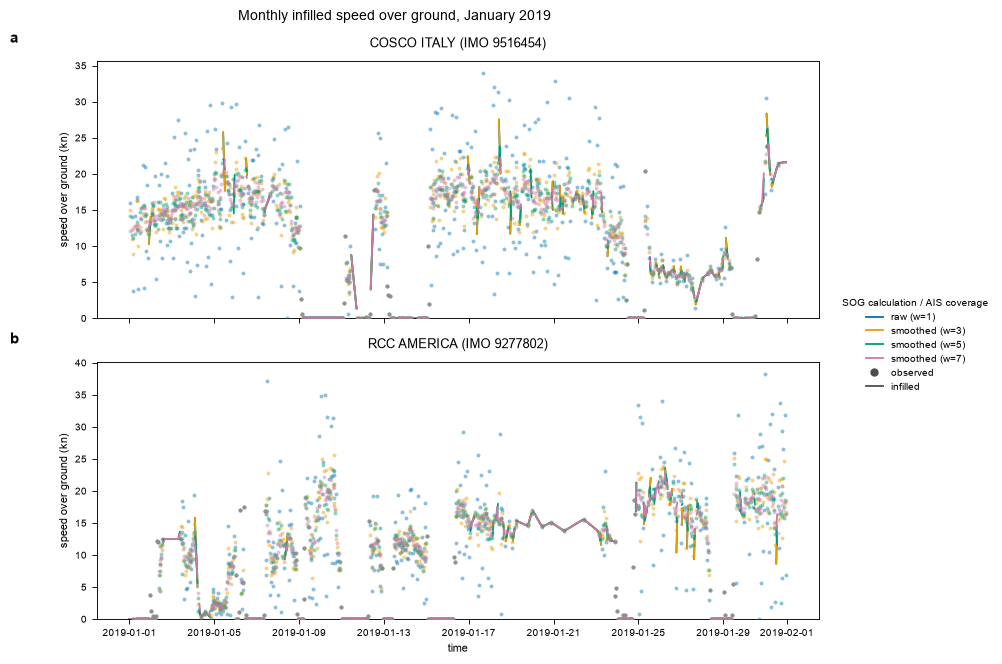

COSCO ITALY (IMO 9516454):
 window  mean(v^3)/(mean v)^3
      1               1.94291
      3               1.32063
      5               1.27266
      7               1.25872
RCC AMERICA (IMO 9277802):
 window  mean(v^3)/(mean v)^3
      1              2.060983
      3              1.413573
      5              1.355567
      7              1.336048


In [4]:
plot_month = pd.Period("2019-01", freq="M")
vessels = list(cfg)
smoothing_windows = cfg.run["smoothing_windows"]
method_colours = dict(zip(smoothing_windows, ["#0072B2", "#E69F00", "#009E73", "#CC79A7"]))
fig, axes = plt.subplots(len(vessels), 1, figsize=(10.2, 6.8), sharex=True, constrained_layout=True)
fig.get_layout_engine().set(rect=(0.04, 0.04, 0.80, 0.96))
axes = np.atleast_1d(axes)
for ax, v in zip(axes, vessels):
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    monthly = vessel_spine[(vessel_spine.ts.dt.to_period("M") == plot_month) & ~vessel_spine.is_inactive].copy()
    observed = monthly.loc[~monthly.is_interpolated]
    infilled = monthly.loc[monthly.is_interpolated].copy()
    # Draw each reception gap separately so infill never implies continuity across AIS observations.
    infilled["gap_id"] = infilled.ts.diff().gt(pd.Timedelta(hours=1)).cumsum()
    for window in smoothing_windows:
        speed_column = f"sog_w{window}"
        for _, gap in infilled.groupby("gap_id"):
            ax.plot(gap.ts, gap[speed_column], color=method_colours[window], lw=1.3, solid_capstyle="round", zorder=2)
        ax.scatter(observed.ts, observed[speed_column], s=8, color=method_colours[window],
                   alpha=0.45, linewidths=0, rasterized=True, zorder=3)
    ax.set_ylabel("speed over ground (kn)")
    panel_heading(ax, chr(97 + list(cfg).index(v)), f"{v.shipnames[0]} (IMO {v.imo})")
    ax.set_ylim(bottom=0)
    ax.set_axisbelow(True)

method_handles = [
    plt.Line2D([], [], color=method_colours[window], lw=1.3, label=("raw (w=1)" if window == 1 else f"smoothed (w={window})"))
    for window in smoothing_windows
]
activity_handles = [
    plt.Line2D([], [], color="#4D4D4D", marker="o", linestyle="None", markersize=5, label="observed"),
    plt.Line2D([], [], color="#4D4D4D", lw=1.3, label="infilled"),
]
right_legend(fig, [*method_handles, *activity_handles], title="SOG calculation / AIS coverage")
axes[-1].set_xlabel("time")
fig.suptitle(f"Monthly infilled speed over ground, {plot_month.strftime('%B %Y')}", x=0.42, ha="center", fontsize=10)
plt.show()

for v in cfg:
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    active = vessel_spine[~vessel_spine.is_inactive]
    bias = pd.DataFrame({"window": cfg.run["smoothing_windows"],
                         "mean(v^3)/(mean v)^3": [activity.cubic_bias(active[f"sog_w{w}"]) for w in cfg.run["smoothing_windows"]]})
    print(f"{v.shipnames[0]} (IMO {v.imo}):")
    print(bias.to_string(index=False))

In [5]:
_disabled_duplicate = """Duplicate standalone chart intentionally removed.
vessel_id = f"{v.shipnames[0]} (IMO {v.imo})"
vessel_estimates = specs.build_estimates(v, cfg)
env = cfg.defaults["fleet_speed_envelope"].get(v.require_spec("ship_type"))
fig, ax = plt.subplots(figsize=(11, 4))
if env is not None:
    ax.axhspan(env["min_kn"], env["max_kn"], color=COLOUR["green"], alpha=0.12,
               label=f"observed fleet envelope {env['min_kn']}–{env['max_kn']} kn")
    ax.axhline(env["max_kn"], color=COLOUR["green"], ls="--", lw=1)
for i, (name, e) in enumerate(vessel_estimates.items()):
    ax.scatter([i], [e.design_speed_kn], s=180, zorder=3,
               color=COLOUR["blue"] if env is None or e.within_fleet_envelope else COLOUR["pink"])
    ax.annotate(f"{e.design_speed_kn:.2f} kn\n{e.mcr_kw:,.0f} kW",
                (i, e.design_speed_kn), textcoords="offset points", xytext=(14, -6))
ax.set_xticks(range(len(vessel_estimates)))
ax.set_xticklabels([vessel_estimates[k].label for k in vessel_estimates])
ax.set_ylabel("design speed (kn)")
ax.set_ylim(0, 32)
ax.set_title(f"Design speed estimates : {vessel_id}")
if env is not None:
    ax.legend(loc="lower right", fontsize=9)
plt.show()
"""


### Section 1.7 Coverage : and a finding the specification did not anticipate

`docs/METHODOLOGY.md` Section 1.7 and Section 4.5 treat the coverage correction as negligible, on the
strength of 2024 alone (99.98%). Measured across the full period it is not.

More importantly, the gaps are two different phenomena and they need opposite treatment:

* Scattered short gaps are thin AIS reception. The vessel was trading and hours were
  missed, so $E/\text{coverage}$ correctly recovers them.
* Contiguous absences are the hull out of service. Zero presence hours *and* zero port
  calls, from two independent endpoints. Scaling those up would fabricate voyages.

Applied uniformly, the Section 4.5 correction would multiply 2019 by 2.77× for a ship that was
laid up for 282 days. So `coverage_active` : observed over *in-service* hours : is what
the correction divides by.

In [6]:
coverage = pd.concat([
    activity.coverage_by_year(pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")).assign(
        ship=v.shipnames[0], IMO=v.imo
    )
    for v in cfg
], ignore_index=True)
display(coverage[["ship", "IMO", "year", "coverage_raw", "coverage_active"]].style.format({
    "coverage_raw": "{:.2%}", "coverage_active": "{:.2%}",
}).set_caption("Section 1.7 coverage by vessel: raw counts a lay-up as missing data; active does not"))

print("Out-of-service windows (no presence AND no port calls):")
for v in cfg:
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    gaps = activity.find_gaps(vessel_spine, min_hours=cfg.run["inactivity_gap_days"] * 24)
    print(f"  {v.shipnames[0]} (IMO {v.imo}):")
    if gaps.empty:
        print("    none")
    for g in gaps.itertuples():
        print(f"    {g.start_ts:%Y-%m-%d} to {g.end_ts:%Y-%m-%d}  "
              f"{int(g.hours):,} h ({int(g.hours)//24} d)")

,ship,IMO,year,coverage_raw,coverage_active
0,COSCO ITALY,9516454,2017,82.02%,82.02%
1,COSCO ITALY,9516454,2018,71.15%,88.39%
2,COSCO ITALY,9516454,2019,36.06%,81.97%
3,COSCO ITALY,9516454,2020,72.72%,92.34%
4,COSCO ITALY,9516454,2021,93.18%,93.18%
5,COSCO ITALY,9516454,2022,97.01%,97.01%
6,COSCO ITALY,9516454,2023,99.81%,99.81%
7,COSCO ITALY,9516454,2024,99.98%,99.98%
8,RCC AMERICA,9277802,2017,85.63%,85.63%
9,RCC AMERICA,9277802,2018,88.71%,88.71%


Out-of-service windows (no presence AND no port calls):
  COSCO ITALY (IMO 9516454):
    2019-06-10 to 2020-03-18  6,772 h (282 d)
    2018-05-19 to 2018-07-29  1,708 h (71 d)
  RCC AMERICA (IMO 9277802):
    2024-10-28 to 2024-12-31  1,551 h (64 d)


### Chart 3: hourly tracks for both vessels

This world map places every observed vessel-hour at its 0.01 degree cell centroid. Comparing
the two tracks confirms the spatial coverage used in the activity and emissions calculations.

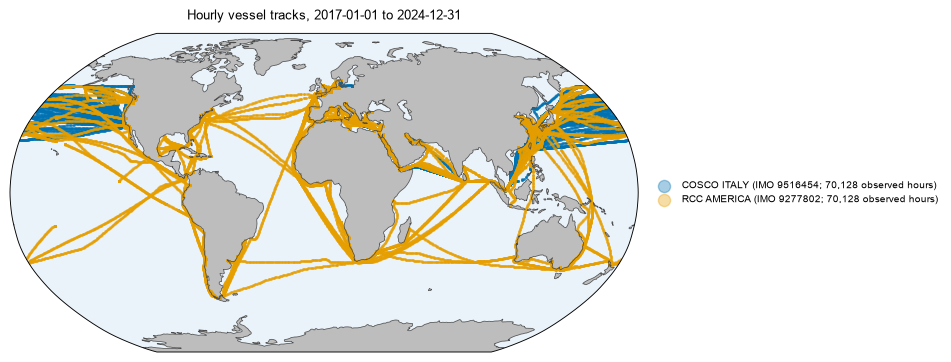

In [7]:
track_colours = [COLOUR["blue"], COLOUR["orange"]]
fig = plt.figure(figsize=(9.4, 5.4), constrained_layout=True)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor=COLOUR["gray"])
ax.add_feature(cfeature.OCEAN, facecolor="#EAF2FA")
ax.coastlines(linewidth=0.55, color="#4D4D4D")
# Geographic reference is supplied by coastlines; gridlines would compete with the tracks.

for v, colour in zip(cfg, track_colours):
    vessel_track = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet").dropna(
        subset=["lat", "lon"]
    )
    scatter_kwargs = {"s": 1.2, "alpha": 0.35, "color": colour,
                      "label": f"{v.shipnames[0]} (IMO {v.imo}; {len(vessel_track):,} observed hours)"}
    scatter_kwargs["transform"] = ccrs.PlateCarree()
    ax.scatter(vessel_track.lon, vessel_track.lat, **scatter_kwargs)

panel_heading(ax, None, f"Hourly vessel tracks, {cfg.start_date} to {cfg.end_date}")
ax.legend(
    markerscale=8,
    fontsize=7,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
)
plt.show()

# Section 2 : Ship specifications and parameters

What this step does. Assembles the technical parameters the emission model needs, and is
explicit that two of them cannot be observed from any free source.

Inputs : Equasis, public vessel registers, published regressions.
Outputs : `config/vessel_specs.yaml`, every estimated field carrying `value`, `source`
and `method`.

### Section 2.1 TEU capacity

IMO Table 17 indexes container ships by TEU; Equasis does not carry it. Invert the beam
relation:

$$B = 3.27\,\mathrm{TEU}^{0.29} \quad\Longrightarrow\quad
  \mathrm{TEU} = \left(\frac{B}{3.27}\right)^{1/0.29}$$

*Source: Cepowski & Chorab (2021), Ocean Engineering 238, 109727 : beam relation, fitted on
215 container designs built 2015–2020.*

Beam is the better proxy for container ships because it sets the on-deck row count. Table 17 size basis is always read from its source row: container ships use TEU, several passenger/service rows use GT, and gas carriers use cargo volume (cbm). A gas carrier therefore requires configured `cbm_capacity`; DWT is never silently substituted.

### Section 2.2 Design speed and installed power : four estimation approaches

Estimate A : IMO EEXI curve fit

The EEXI curve-fit formulas used to estimate reference design speed and installed main-engine
power for each vessel are expressed in equations (2.1) and (2.2):

$$V_{\mathrm{ref,avg}} = A\,B^C\tag{2.1}$$

$$MCR_{\mathrm{avg}} = D\,E^F.\tag{2.2}$$

where $V_{\mathrm{ref,avg}}$ is the estimated reference design speed (kn); $MCR_{\mathrm{avg}}$
is the estimated installed main-engine power (kW); and $A$, $C$, $D$, and $F$ are the
ship-type-specific coefficients in IMO Resolution MEPC.333(76). $B$ and $E$ are the capacity
parameters used for the speed and power curves, respectively.

*Source: IMO Resolution MEPC.333(76) (2021), Appendix.* For containerships, $B=\min(\mathrm{DWT},
80{,}000)$ and $E=\min(\mathrm{DWT},95{,}000)$; the coefficients are $A=3.2395$, $C=0.18294$,
$D=0.5042$, and $F=1.03046$. Thus, for COSCO ITALY (156,610 DWT), both caps bind and
equations (2.1) and (2.2) give $V_{\mathrm{ref}}=25.55$ kn and `MCR` = 67,912 kW. The
resolution writes $P_{ME}$ for installed power; this project calls it `MCR` throughout,
because the Fourth GHG Study uses that symbol for instantaneous demand.

Estimate B : Admiralty coefficient, calibrated reference-power curve

The independent naval-architecture estimate first derives design speed from the Froude number
and then applies the Admiralty relation for propulsion power at that reference speed:

$$V = \frac{Fn\sqrt{g\,L_{BP}}}{0.5144}\ [\mathrm{kn}]\tag{2.3}$$

$$P_{\mathrm{ref}} = \frac{\Delta^{2/3}V^3}{C_{\mathrm{adm}}}.\tag{2.4}$$

where $Fn$ is the Froude number (–); $g$ is gravitational acceleration (m s$^{-2}$);
$L_{BP}$ is length between perpendiculars (m); $V$ is design speed (kn); $\Delta$ is
displacement (t); and $C_{\mathrm{adm}}$ is the dimensionless Admiralty coefficient.

*Sources: Froude number, standard naval architecture. $C_{\mathrm{adm}}$ is calibrated on
Charchalis (2014), Journal of KONES 21(2), Table 1: 17 container ships with matched speed,
power, and displacement; median $C_{\mathrm{adm}}=482$.* Displacement is estimated by two
routes that bracket a real convention difference:

$$\Delta=C_B\,L_{BP}\,B\,T\,\rho \qquad\text{and}\qquad \Delta=\mathrm{DWT}/0.80.\tag{2.5}$$

Estimate C : sourced specification. Installed power and service speed from a shipbuilder or
class-society record for the specific hull. *Source: vessel-specific shipbuilder or
class-society documentation, when obtainable.* This is an open item for COSCO ITALY; the
pipeline raises rather than guessing. A sourced C record must also state the load fraction and
condition at which its speed was reported.

Estimate D : EPA DWT-to-power regression, paired with a documented reference speed

The EPA regression estimates rated container-vessel main-engine power directly from DWT:

$$MCR_{D,\mathrm{hp}}=0.80\,\mathrm{DWT}-749.4,\qquad
MCR_{D,\mathrm{kW}}=0.745699872\,MCR_{D,\mathrm{hp}}.\tag{2.6}$$

where $MCR_{D,\mathrm{hp}}$ is estimated rated main-engine power (hp), DWT is deadweight
(t), and $MCR_{D,\mathrm{kW}}$ is estimated installed main-engine power (kW). For COSCO
ITALY, equation (2.6) gives 124,539 hp = 92,868 kW. The regression does not estimate speed,
so the container-ship D scenario pairs its MCR with the independent Froude-speed range in Estimate B.

*Source: EPA (2000), Table 4-3; reproduced by Merk (2014), ITF Discussion Paper 2014-20.*
The container fit has $R^2=0.59$ and a typical DWT range of 20,000–70,000 t, making COSCO
ITALY (156,610 DWT) an extrapolation. This is therefore a high-uncertainty sensitivity
scenario. It estimates main-engine power directly; it does not reverse IMO Table 17 auxiliary
operating loads. For the vehicle carrier, EPA power is paired with Estimate A's EEXI reference
speed because no vehicle-carrier Froude calibration is configured.

Each scenario carries a reference speed, power scale, sourced reference-load fraction $f_{\mathrm{ref}}$,
and speed exponent $n$. These are carried into the hourly calculation:

$$Load_i=\min\left[f_{\mathrm{ref}}\left(\frac{\overline{SOG}_i}{V_{\mathrm{ref}}}\right)^n,1\right],
\qquad \dot{W}_{ME,i}=MCR\cdot Load_i.\tag{2.7}$$

where $\overline{SOG}_i$ is smoothed speed over ground in hour $i$ (kn); $Load_i$ is the
dimensionless main-engine load fraction; and $\dot{W}_{ME,i}$ is main-engine power demand
in hour $i$ (kW). *Source: propeller (cube) law; simplified from Equation (8) in the Fourth
IMO GHG Study 2020, Section 2.2.5.* Estimate A uses $f_{\mathrm{ref}}=0.75$ at the EEXI
reference condition; Estimate D uses 0.83 with EPA service speed and 0.75 when paired with
EEXI speed. The Admiralty source does not resolve its installed-MCR fraction, so B remains a
provisional reference-power formulation at $f_{\mathrm{ref}}=1.0$.

In [8]:
rows = []
for v in cfg:
    ship_type = v.require_spec("ship_type")
    table17_size = (f"{specs.resolve_teu(v, cfg):,.0f} TEU (derived)"
                    if ship_type == "container"
                    else f"{v.require_spec('dwt'):,.0f} t DWT")
    rows.append({
        "ship": v.shipnames[0],
        "IMO": v.imo,
        "ship type": ship_type,
        "flag": v.require_spec("flag"),
        "built": v.require_spec("year_built"),
        "DWT (t)": v.require_spec("dwt"),
        "GT (t)": v.require_spec("gt"),
        "LOA (m)": v.specs["loa_m"].value if "loa_m" in v.specs else np.nan,
        "beam (m)": v.specs["beam_m"].value if "beam_m" in v.specs else np.nan,
        "draught (m)": v.specs["draught_m"].value if "draught_m" in v.specs else np.nan,
        "engine type": v.require_spec("engine_type"),
        "IMO Table 17 size input": table17_size,
        "power estimates": ", ".join(v.resolve_power_estimates(cfg.run["power_estimates"])),
    })

display(pd.DataFrame(rows).style.format({
    "DWT (t)": "{:,.0f}", "GT (t)": "{:,.0f}",
    "LOA (m)": "{:.1f}", "beam (m)": "{:.1f}", "draught (m)": "{:.1f}",
}, na_rep=":").set_caption("Section 2 : vessel specifications and parameters used in the emissions model"))

for v in cfg:
    if "beam_m" in v.specs:
        teu = specs.resolve_teu(v, cfg)
        print(f"{v.shipnames[0]} (IMO {v.imo}): TEU inverted from beam {v.require_spec('beam_m')} m: {teu:,.0f} [estimated]")
    else:
        print(f"{v.shipnames[0]} (IMO {v.imo}): TEU inversion not applicable: beam_m is not required for this vehicle carrier.")
validation_rows = []
estimate_rows = []
for v in cfg:
    if {"lbp_m", "beam_m", "draught_m"}.issubset(v.specs):
        validation = pd.DataFrame(specs.validate_hull_relations(v, cfg.defaults)).T.reset_index(names="relation")
        validation.insert(0, "IMO", v.imo)
        validation.insert(0, "ship", v.shipnames[0])
        validation_rows.append(validation)
    else:
        validation_rows.append(pd.DataFrame([{"ship": v.shipnames[0], "IMO": v.imo, "relation": "not applicable", "predicted": np.nan, "observed": np.nan, "error_pct": np.nan}]))
    for estimate in specs.build_estimates(v, cfg).values():
        estimate_rows.append({"ship": v.shipnames[0], "IMO": v.imo, "estimate": estimate.label, "design speed (kn)": estimate.design_speed_kn, "MCR (kW)": estimate.mcr_kw, "within fleet envelope": estimate.within_fleet_envelope, "estimated": estimate.estimated})
display(pd.concat(validation_rows, ignore_index=True).style.format({"predicted": "{:.1f}", "observed": "{:.1f}", "error_pct": "{:.1f}"}).set_caption("Section 2  Cepowski and Chorab DWT relations by vessel"))
display(pd.DataFrame(estimate_rows).style.format({"design speed (kn)": "{:.2f}", "MCR (kW)": "{:,.0f}"}).set_caption("Section 2.2  Three estimates by vessel"))


,ship,IMO,ship type,flag,built,DWT (t),GT (t),LOA (m),beam (m),draught (m),engine type,IMO Table 17 size input,power estimates
0,COSCO ITALY,9516454,container,HKG,2014,"156,610","154,592",365.9,51.2,16.0,SSD,"13,174 TEU (derived)","A, B, D"
1,RCC AMERICA,9277802,vehicle,BHS,2003,"21,182","57,718",:,:,:,SSD,"21,182 t DWT","A, D"


COSCO ITALY (IMO 9516454): TEU inverted from beam 51.2 m: 13,174 [estimated]
RCC AMERICA (IMO 9277802): TEU inversion not applicable: beam_m is not required for this vehicle carrier.


,ship,IMO,relation,predicted,observed,error_pct
0,COSCO ITALY,9516454,lbp,344.4,345.0,-0.2
1,COSCO ITALY,9516454,beam,52.8,51.2,3.2
2,COSCO ITALY,9516454,draught,15.8,16.0,-1.4
3,RCC AMERICA,9277802,not applicable,nan,nan,nan


,ship,IMO,estimate,design speed (kn),MCR (kW),within fleet envelope,estimated
0,COSCO ITALY,9516454,A (EEXI curve fit),25.55,"67,912",False,True
1,COSCO ITALY,9516454,"B (Admiralty, calibrated)",22.62,"78,258",True,True
2,COSCO ITALY,9516454,D (EPA DWT power + FROUDE speed),22.62,"92,868",True,True
3,RCC AMERICA,9277802,A (EEXI curve fit),19.96,"14,086",None,True
4,RCC AMERICA,9277802,D (EPA DWT power + EEXI speed),19.96,"13,282",None,True


### Chart 2 : comparison of design-speed and installed-power estimates

The EEXI containership capacity caps are applied before evaluating the curve fit. For COSCO
ITALY, this gives 25.55 kn and 67,912 kW, rather than the invalid uncapped values of 28.89 kn
and 113,673 kW. The caps are part of MEPC.333(76), not a post-hoc correction.

The figure compares the available estimate pairs and the observed modern container-fleet
speed envelope (6.0–24.5 kn; Cepowski & Chorab, Table 1). Their spread is propagated through
the CO₂ scenarios as parameter uncertainty; no estimate is treated as the primary truth.

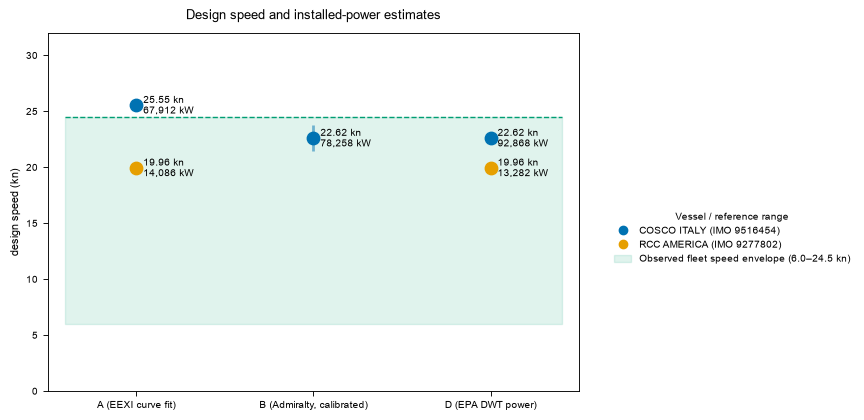

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 4.4), layout="constrained")
fig.get_layout_engine().set(rect=(0.06, 0.10, 0.76, 0.93))

method_labels = {
    "A": "A (EEXI curve fit)",
    "B": "B (Admiralty, calibrated)",
    "C": "C (sourced specification)",
    "D": "D (EPA DWT power)",
}

estimate_methods = []
for v in cfg:
    estimate_methods.extend(specs.build_estimates(v, cfg).keys())
estimate_methods = list(dict.fromkeys(estimate_methods))
estimate_x = {method: index for index, method in enumerate(estimate_methods)}

ship_colours = dict(zip([v.imo for v in cfg], OKABE_ITO))
ship_handles = [
    plt.Line2D([], [], color=ship_colours[v.imo], marker="o", linestyle="None",
               label=f"{v.shipnames[0]} (IMO {v.imo})")
    for v in cfg
]

for v in cfg:
    vessel_estimates = specs.build_estimates(v, cfg)
    env = cfg.defaults["fleet_speed_envelope"].get(v.require_spec("ship_type"))
    vessel_x = [estimate_x[name] for name in vessel_estimates]

    if env is not None:
        ax.fill_between(
            [min(vessel_x) - 0.4, max(vessel_x) + 0.4],
            env["min_kn"],
            env["max_kn"],
            color=COLOUR["green"],
            alpha=0.12,
            zorder=0,
        )
        ax.hlines(
            env["max_kn"],
            min(vessel_x) - 0.4,
            max(vessel_x) + 0.4,
            color=COLOUR["teal"],
            linestyle="--",
            linewidth=1,
            zorder=1,
        )

    for name, estimate in vessel_estimates.items():
        x = estimate_x[name]

        ax.scatter(
            x,
            estimate.design_speed_kn,
            s=80,
            color=ship_colours[v.imo],
            zorder=3,
        )
        ax.annotate(
            f"{estimate.design_speed_kn:.2f} kn\n{estimate.mcr_kw:,.0f} kW",
            (x, estimate.design_speed_kn),
            textcoords="offset points",
            xytext=(5, -6),
            fontsize=7,
        )

        if name == "B":
            lo, hi = estimate.variants["speed_kn_range"]
            ax.vlines(
                x,
                lo,
                hi,
                color=ship_colours[v.imo],
                linewidth=2,
                alpha=0.5,
            )

ax.set_xticks(range(len(estimate_methods)))
ax.set_xticklabels([method_labels[name] for name in estimate_methods])
ax.set_xlim(-0.5, len(estimate_methods) - 0.5)
ax.set_ylim(0, 32)
ax.set_ylabel("design speed (kn)")
ax.set_title("Design speed and installed-power estimates", pad=10)

envelope_handle = Patch(
    facecolor=COLOUR["green"],
    edgecolor=COLOUR["teal"],
    alpha=0.12,
    label="Observed fleet speed envelope (6.0–24.5 kn)",
)

right_legend(fig, [*ship_handles, envelope_handle], title="Vessel / reference range")

plt.show()

# Section 3 : Fuel type and emission factors

What this step does. Assigns a fuel to every vessel-hour and attaches the corresponding
emission factor and specific fuel consumption.

Inputs : IMO Fourth GHG Study Tables 19 and 21; Marine Regions ECA polygons (MARPOL
Annex VI Reg. 14); `voyage_leg` from Section 1.
Outputs : `fuel_assignment` at vessel-hour grain.

### Section 3.1 Assignment rule

A vessel-hour burns distillate (MDO/MGO) when *any* of the following holds, and
residual (HFO) otherwise:

1. the main engine is high-speed : not applicable here (SSD);
2. the position falls inside an ECA polygon : point-in-polygon;
3. the hour belongs to a voyage leg between two EU ports.

*Source: Selin et al. (2021), following the IMO Fourth GHG Study.*

Condition 3 is read from an actual port-call sequence, which is a genuine improvement on the
EEZ proxy that gridded-only data would have forced.

### Section 3.2 The IMO 2020 sulphur cap is immaterial to CO₂

The study period straddles the 0.50% global sulphur cap of 1 January 2020. For CO₂ this
changes nothing: the Fourth GHG Study assigns low-sulphur HFO the same carbon content and
emission factor as HFO (Table 21, LSHFO 1.0% → 3.114). Scrubber fitting affects SOx only.
There is deliberately no fuel-switch date branch anywhere in the code.

*Source: IMO Fourth GHG Study 2020, Table 21 (printed p.74).*

In [10]:
fuel_assign = pd.concat([
    pd.read_parquet(INTERIM / f"fuel_assignment_{v.imo}.parquet").assign(ship=v.shipnames[0], IMO=v.imo)
    for v in cfg
], ignore_index=True)
total = len(fuel_assign)
print(f"{total:,} vessel-hours")
print(f"  inside an ECA:    {int(fuel_assign.in_eca.sum()):,} "
      f"({fuel_assign.in_eca.mean():.1%})")
print(f"  on an EU->EU leg: {int(fuel_assign.is_eu_eu_leg.sum()):,} "
      f"({fuel_assign.is_eu_eu_leg.mean():.1%})")

ef = cfg.factors["emission_factors"]["fuels"]
split = (fuel_assign.groupby(["ship", "IMO", "fuel_type"]).size().rename("hours").reset_index()
         .assign(share=lambda d: d["hours"] / d.groupby("IMO")["hours"].transform("sum"),
                 ef_f=lambda d: d["fuel_type"].map(lambda fuel: ef[fuel]["ef_f"])))
display(split.style.format({"hours": "{:,}", "share": "{:.1%}"})
        .set_caption("Section 3.3  fuel split by vessel and Table 21 emission factors (g CO2 / g fuel)"))

print("\nECA hours by area (corroborates the port-call pattern independently):")
print(fuel_assign[fuel_assign.in_eca].eca_area.value_counts().to_string())

140,256 vessel-hours
  inside an ECA:    12,799 (9.1%)
  on an EU->EU leg: 6,422 (4.6%)


,ship,IMO,fuel_type,hours,share,ef_f
0,COSCO ITALY,9516454,HFO,"64,841",92.5%,3.114000
1,COSCO ITALY,9516454,MDO,"5,287",7.5%,3.206000
2,RCC AMERICA,9277802,HFO,"58,606",83.6%,3.114000
3,RCC AMERICA,9277802,MDO,"11,522",16.4%,3.206000



ECA hours by area (corroborates the port-call pattern independently):
eca_area
North Sea area                      6581
North American area 1               4406
North American area 2               1642
Baltic Sea area                      147
United States Caribbean sea area      23


# Section 4 : Calculate CO2 emissions

What this step does. Converts the hourly activity series into CO₂ mass per hour, summed
to ship-year, for every scenario.

Inputs : `vessel_hour`, `vessel_specs`, `fuel_assignment`, IMO Tables 16, 17, 19, 21.
Outputs : `emissions_hour`, `emissions_year`, both scenario-keyed. Table 17 size basis is explicit: a gas carrier requires configured cargo volume (`cbm_capacity`) rather than falling through to DWT.

### Section 4.2 Main-engine power demand

$$Load_i = f_{\mathrm{ref}}\left(\frac{\overline{SOG}_i}{V_{\mathrm{ref}}}\right)^{n},\ \text{capped at }1.0
\qquad \dot W_{ME,i} = \mathrm{MCR}\cdot Load_i$$

*Source: `docs/METHODOLOGY.md` Section 4.2; the cubic law is standard propulsion theory.*

with $\dot W_{ME,i}=0$ below 7% MCR and in the At berth / Anchored modes. The current default
is $n=3$, retained as a configurable per-estimate parameter. This is a calm-water, clean-hull
SOG proxy: hourly draught/loading state, STW/current, weather, and fouling are not available
from the selected GFW products and are not imputed.
*Source: IMO Fourth GHG Study 2020, printed p.70 : "At engine loads below 7%, fuel
consumption and all the emissions derived from the main engine are assumed to be zero."*

### Section 4.4 Load-corrected specific fuel consumption : IMO equation (10), verbatim

$$SFC_{ME,i} = SFC_{base}\cdot\underbrace{\left(0.455\,Load_i^{2} − 0.710\,Load_i + 1.280\right)}_{CF_L}$$

*Source: IMO Fourth GHG Study 2020, equation (10), printed p.71.*

The quadratic minimises at $Load = 0.710/(2\times0.455) = 0.78$, matching the study's stated
~80% MCR optimum : an internal check that the coefficients are transcribed correctly, and one
the test suite asserts.

Auxiliary engines and boilers are not corrected : IMO equation (11):

$$FC_{AE|BO,i} = SFC_{base}\cdot \dot W_{AE|BO,i}$$

### Section 4.5 Hourly and annual CO₂

$$FC_i = \left[\dot W_{ME,i}SFC_{ME,i} + \dot W_{AE,i}SFC_{base,AE}
        + \dot W_{BO,i}SFC_{base,BO}\right]\Delta t \quad[\text{g fuel}]$$
$$E_{CO_2,i} = FC_i\cdot EF_f / 10^{6}\quad[\text{t}], \qquad
  E_{ship,y} = \sum_i E_{CO_2,i}$$

*Source: IMO Fourth GHG Study 2020 Section 2.2; emission factors from Table 21.*

$LLF$ does not appear: CO₂'s low-load factor is 1.00 at every load (Table 20), because CO₂
varies directly with fuel consumption, which is already load-dependent.

### Section 4.1 Operating mode : IMO Table 16, and one documented departure

Table 16 assigns one of five phases from speed, main-engine load, distance to port and
distance to coast. The five columns are an ordered ladder; the first applicable wins.

*Source: IMO Fourth GHG Study 2020, Table 16, printed p.66.*

Two things about this table are worth stating, because both differ from
`docs/METHODOLOGY.md` Section 4.1:

The 'Port 1–5 nm' column is tanker-only. The source footnotes it: *"Applicable to
chemical tankers, liquified gas tankers, oil tankers and other liquids tankers only"* :
liquid tankers are lightered offshore and so can berth within 5 nm of port. The methodology
document reproduces the column without that restriction, which would let a container ship
count as At berth up to 5 nm out. The source is followed here.

At berth is determined from port-visit intervals, not distance. The source separates
berth from anchor by distance because it had no better signal, and Section 4.1 flags the exposure.
We have a better one: a GFW port-visit event asserts, from a different endpoint and with a
confidence score, that the vessel was in port between two timestamps. Using distance to
anchorage coordinates instead put only 1,143 h at berth against 17,427 h actually in port.
`run.use_port_visit_intervals: false` restores strict Table 16 for comparison. The same port
intervals delimit speed smoothing, so a centred window cannot smear berth speed into a departure
or cruise speed before this classification.

,ship,IMO,operating_mode,hours,share
0,COSCO ITALY,9516454,anchored,"2,438",4.0%
1,COSCO ITALY,9516454,at_berth,"15,287",24.8%
2,COSCO ITALY,9516454,manoeuvring,433,0.7%
3,COSCO ITALY,9516454,normal_cruising,"1,015",1.6%
4,COSCO ITALY,9516454,slow_transit,"42,475",68.9%
5,RCC AMERICA,9277802,anchored,"5,334",7.8%
6,RCC AMERICA,9277802,at_berth,"12,278",17.9%
7,RCC AMERICA,9277802,manoeuvring,708,1.0%
8,RCC AMERICA,9277802,normal_cruising,"8,428",12.3%
9,RCC AMERICA,9277802,slow_transit,"41,829",61.0%


mode,at_berth,anchored,manoeuvring,sea
boiler kW,630,630,630,0
auxiliary kW,1300,1800,3250,2050


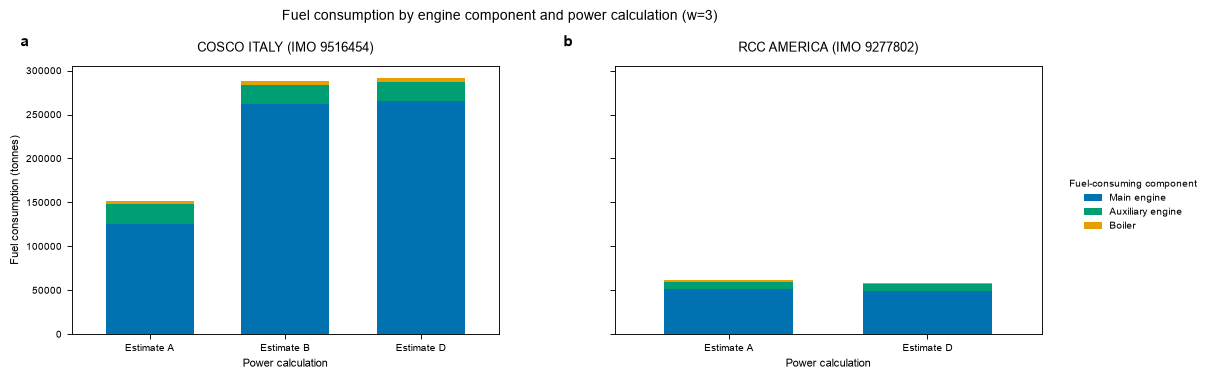

In [11]:
hourly = pd.concat([
    pd.read_parquet(INTERIM / f"emissions_hour_{v.imo}.parquet").assign(ship=v.shipnames[0], IMO=v.imo)
    for v in cfg
], ignore_index=True)
yearly = pd.read_parquet(INTERIM / f"emissions_year_{vessel.imo}.parquet")

ref = hourly[hourly.scenario_id == f"{cfg.run['power_estimates'][0]}_w3"]
mode_split = (ref.groupby(["ship", "IMO", "operating_mode"]).size().rename("hours").reset_index()
              .assign(share=lambda d: d["hours"] / d.groupby("IMO")["hours"].transform("sum")))
display(mode_split.style.format({"hours": "{:,}", "share": "{:.1%}"})
        .set_caption("Section 4.1  operating-mode split by vessel (estimate A, w=3)"))

t17 = cfg.factors["auxiliary_boiler_power"]
band = next(b for b in t17["ship_types"]["container"]["bands"] if b["min"] == 12000)
display(pd.DataFrame({"mode": t17["modes"], "boiler kW": band["boiler"],
                      "auxiliary kW": band["auxiliary"]})
        .set_index("mode").T.style.set_caption(
            "Section 4.3  IMO Table 17 : container 12,000–14,499 TEU"))

component_columns = {
    "Main engine": "fc_me_g",
    "Auxiliary engine": "fc_ae_g",
    "Boiler": "fc_bo_g",
}
comparison_window = 3
fuel_component_total_tonnes = (
    hourly.loc[hourly["smoothing_window"].eq(comparison_window)]
    .groupby(["ship", "IMO", "power_estimate"], observed=True)[list(component_columns.values())]
    .sum()
    .rename(columns={value: key for key, value in component_columns.items()})
) / 1e6

component_colours = {
    "Main engine": COLOUR["blue"],
    "Auxiliary engine": COLOUR["teal"],
    "Boiler": COLOUR["gold"],
}
fig, axes = plt.subplots(1, len(list(cfg)), figsize=FIG_PANEL, sharey=True, layout="constrained")
fig.get_layout_engine().set(rect=(0.04, 0.08, 0.80, 0.91), wspace=0.10)
axes = np.atleast_1d(axes)
for ax, v in zip(axes, cfg):
    vessel_components = fuel_component_total_tonnes.xs(v.imo, level="IMO")
    power_order = [
        estimate for estimate in cfg.run["power_estimates"]
        if estimate in vessel_components.index.get_level_values("power_estimate")
    ]
    vessel_components = vessel_components.xs(v.shipnames[0], level="ship").reindex(power_order)
    vessel_components.plot(
        kind="bar", stacked=True, ax=ax, width=0.65, legend=False,
        color=[component_colours[column] for column in vessel_components.columns],
    )
    panel_heading(ax, chr(97 + list(cfg).index(v)), f"{v.shipnames[0]} (IMO {v.imo})")
    ax.set_xlabel("Power calculation")
    ax.set_xticklabels([f"Estimate {estimate}" for estimate in power_order], rotation=0)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Fuel consumption (tonnes)")
right_legend(
    fig,
    [Patch(facecolor=colour, edgecolor="none", label=label) for label, colour in component_colours.items()],
    title="Fuel-consuming component",
)
fig.suptitle(
    f"Fuel consumption by engine component and power calculation (w={comparison_window})",
    x=0.42, ha="center", fontsize=10,
)
plt.show()

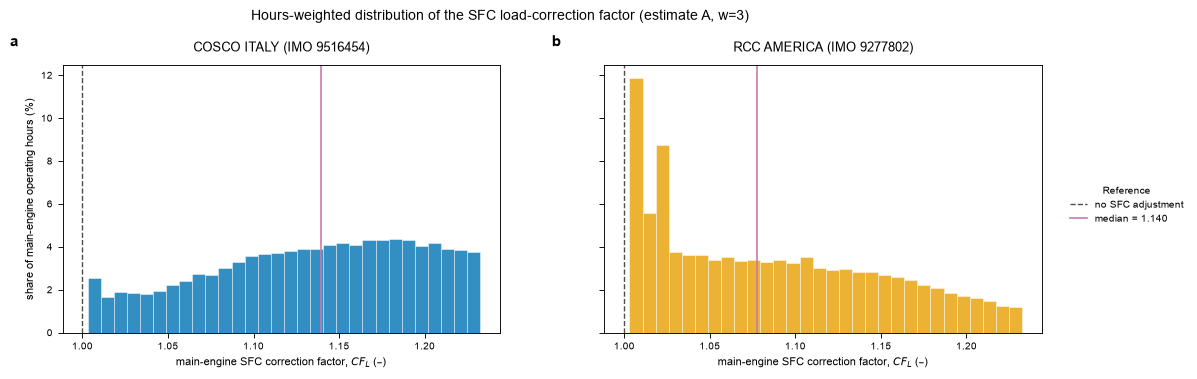

In [12]:
c = cfg.factors["load_correction"]
reference_scenario = f"{cfg.run['power_estimates'][0]}_w3"
reference_hours = hourly[hourly.scenario_id == reference_scenario].copy()
reference_hours = reference_hours[reference_hours.w_me_kw.gt(0)].copy()
reference_hours["cf_l"] = (
    c["a"] * reference_hours.me_load**2
    + c["b"] * reference_hours.me_load
    + c["c"]
)
bins = np.linspace(reference_hours.cf_l.min(), reference_hours.cf_l.max(), 31)
ship_colours = dict(zip([v.imo for v in cfg], [COLOUR["blue"], COLOUR["orange"]]))
fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL, sharex=True, sharey=True, layout="constrained")
fig.get_layout_engine().set(rect=(0.04, 0.08, 0.80, 0.91), wspace=0.08)
for ax, v in zip(axes, cfg):
    vessel_hours = reference_hours[reference_hours.IMO == v.imo]
    weights = np.full(len(vessel_hours), 100 / len(vessel_hours))
    ax.hist(
        vessel_hours.cf_l, bins=bins, weights=weights, color=ship_colours[v.imo],
        alpha=0.80, edgecolor="white", linewidth=0.4,
    )
    ax.axvline(1.0, color=COLOUR["dark_gray"], ls="--", lw=1, label="no SFC adjustment")
    median_cf_l = vessel_hours.cf_l.median()
    ax.axvline(median_cf_l, color=COLOUR["pink"], lw=1.2, label=f"median = {median_cf_l:.3f}")
    ax.set_xlabel("main-engine SFC correction factor, $CF_L$ (–)")
    panel_heading(ax, chr(97 + list(cfg).index(v)), f"{v.shipnames[0]} (IMO {v.imo})")
axes[0].set_ylabel("share of main-engine operating hours (%)")
handles, labels = axes[0].get_legend_handles_labels()
right_legend(fig, handles, title="Reference")
fig.suptitle("Hours-weighted distribution of the SFC load-correction factor (estimate A, w=3)", x=0.42, ha="center", fontsize=10)
plt.show()


### Chart 4 : annual CO₂ under each power estimate

The gap between the available scenario families is the Section 2.2 spread propagating into the result. It is an
uncertainty band, not an error: no free source supplies installed power, so there is no basis
for preferring either.

Years flagged low-confidence had thin AIS reception, and 2018 and 2019 also contain the
out-of-service windows found in Section 1.7.

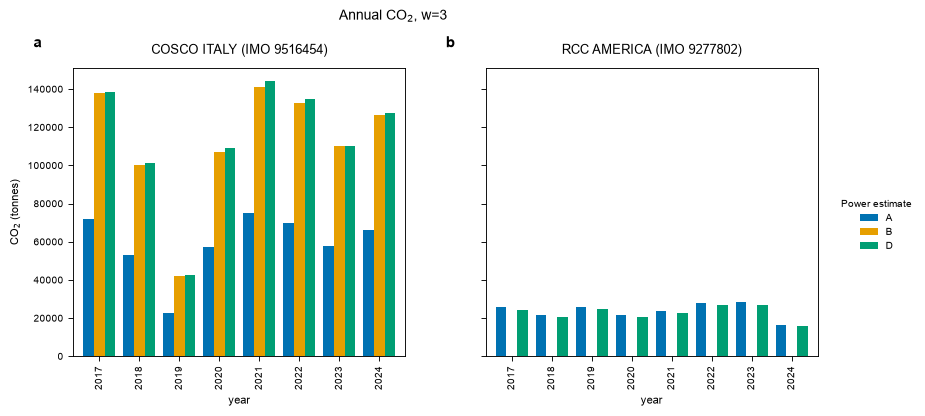

,ship,IMO,year,power_estimate,co2_tonnes
0,COSCO ITALY,9516454,2017,A,"72,023"
1,COSCO ITALY,9516454,2017,B,"137,870"
2,COSCO ITALY,9516454,2017,D,"138,742"
3,COSCO ITALY,9516454,2018,A,"52,841"
4,COSCO ITALY,9516454,2018,B,"100,472"
5,COSCO ITALY,9516454,2018,D,"101,093"
6,COSCO ITALY,9516454,2019,A,"22,873"
7,COSCO ITALY,9516454,2019,B,"42,323"
8,COSCO ITALY,9516454,2019,D,"42,519"
9,COSCO ITALY,9516454,2020,A,"57,100"


,ship,IMO,power_estimate,co2_tonnes
0,COSCO ITALY,9516454,A,"473,408"
1,COSCO ITALY,9516454,B,"897,942"
2,COSCO ITALY,9516454,D,"908,649"
3,RCC AMERICA,9277802,A,"191,745"
4,RCC AMERICA,9277802,D,"182,511"


In [13]:
w = 3
annual_table = pd.concat([
    pd.read_parquet(INTERIM / f"emissions_year_{v.imo}.parquet").query("smoothing_window == @w").assign(ship=v.shipnames[0], IMO=v.imo)
    for v in cfg
], ignore_index=True)[["ship", "IMO", "year", "power_estimate", "co2_tonnes"]]
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4), sharey=True, layout="constrained")
fig.get_layout_engine().set(rect=(0.04, 0.08, 0.80, 0.91), wspace=0.08)
for ax, v in zip(axes, cfg):
    vessel_annual = annual_table[annual_table.IMO == v.imo]
    power_colours = dict(zip(cfg.run["power_estimates"], [COLOUR["blue"], COLOUR["orange"], COLOUR["teal"]]))
    annual_by_power = vessel_annual.pivot_table(index="year", columns="power_estimate", values="co2_tonnes").reindex(columns=cfg.run["power_estimates"])
    annual_by_power.plot(kind="bar", ax=ax, width=0.8, legend=False, color=[power_colours[name] for name in annual_by_power.columns])
    panel_heading(ax, chr(97 + list(cfg).index(v)), f"{v.shipnames[0]} (IMO {v.imo})")
    ax.set_xlabel("year")

axes[0].set_ylabel("CO$_2$ (tonnes)")
right_legend(fig, [Patch(facecolor=power_colours[name], edgecolor="none", label=name) for name in cfg.run["power_estimates"]], title="Power estimate")
fig.suptitle(f"Annual CO$_2$, w={w}", x=0.42, ha="center", fontsize=10)
plt.show()
display(annual_table.style.format({"co2_tonnes": "{:,.0f}"}).set_caption(f"Section 4.5  Annual CO2 (t) by vessel and power estimate, w={w}"))
totals = annual_table.groupby(["ship", "IMO", "power_estimate"], as_index=False).co2_tonnes.sum()
display(totals.style.format({"co2_tonnes": "{:,.0f}"}).set_caption(f"Section 4.5  Eight-year CO2 total (t) by vessel and power estimate, w={w}"))


# Sections 5-6: Allocate and compare with carbon budgets

Country assignment follows Selin et al.'s supplementary Table 1. The fixed configuration map resolves each vessel key before the Global Carbon Budget baseline join.


In [14]:
base = baselines.build_baselines(cfg)
b2024 = base[(base.year == 2024) & (base.country == "China")]
display(b2024[["country", "mtc", "mtco2"]].style.format({"mtc": "{:,.1f}", "mtco2": "{:,.1f}"}).set_caption("Section 6: 2024 China national baseline under the paper-aligned map"))
check = baselines.shipping_cross_check(cfg, 2024)
print(f"GCB International Shipping 2024: {check['mtc']:.2f} MtC = {check['mtco2']:.0f} Mt CO2")


,country,mtc,mtco2
311,China,"3,354.0","12,289.0"


GCB International Shipping 2024: 170.15 MtC = 623 Mt CO2


# Section 7: Compute allocation impacts

COSCO ITALY's options resolve to one national budget. RCC AMERICA's options resolve to three budgets, so the allocation rule is decisive for that vessel.

Following Selin et al.'s Table 2, the table below ranks allocation-country additions by $\Delta E$. With only two ships, it lists every country reached by each allocation option and separates the contribution of each ship; it does not add a top-20 or EU27 row. The bunker-fuel option remains explicitly unavailable because no bunkering-country data are observed.


In [15]:
international_emissions = pd.read_parquet(INTERIM / "international_emissions_year.parquet")
vessels = list(cfg)
ship_impacts = []
for vessel_cfg in vessels:
    with Database() as db:
        vessel_allocation = allocation.allocate(
            db, cfg, international_emissions[international_emissions.imo == vessel_cfg.imo]
        )
        vessel_impacts = impacts.compute_impacts(db, vessel_allocation, base)
    ship_impacts.append(vessel_impacts.assign(ship=vessel_cfg.shipnames[0]))
ship_view = pd.concat(ship_impacts, ignore_index=True)
reference_estimate = cfg.run["power_estimates"][0]
ship_view = ship_view[
    (ship_view.smoothing_window == 3)
    & (ship_view.year == 2024)
    & (ship_view.power_estimate == reference_estimate)
]

ship_names = [vessel_cfg.shipnames[0] for vessel_cfg in vessels]
ship_columns = [f"{ship} ΔE (Mt CO₂)" for ship in ship_names]
table_rows = []

for option in ("flag", "owner", "operator", "manager"):
    by_country = (
        ship_view[ship_view.option == option]
        .pivot_table(index="gcb_name", columns="ship", values="delta_e_mt", aggfunc="sum", fill_value=0)
        .reindex(columns=ship_names, fill_value=0)
        .assign(total_delta_e_mt=lambda d: d.sum(axis=1))
        .sort_values("total_delta_e_mt", ascending=False)
    )
    for rank, (country, allocation_row) in enumerate(by_country.iterrows(), start=1):
        table_rows.append({
            "Allocation option": option.title(),
            "Rank": rank,
            "Country": country,
            **{f"{ship} ΔE (Mt CO₂)": allocation_row[ship] for ship in ship_names},
            "Total ΔE (Mt CO₂)": allocation_row.total_delta_e_mt,
        })

allocation_summary = pd.DataFrame(table_rows)
display(
    allocation_summary.style
    .format({column: "{:.6f}" for column in [*ship_columns, "Total ΔE (Mt CO₂)"]}, na_rep="—")
    .set_caption(
        f"Section 7  Allocation-country additions by ship (2024; power estimate {reference_estimate}, w=3). "
        "Values are ΔE (Mt CO₂); computed options are ranked by total ΔE."
    )
)


,Allocation option,Rank,Country,COSCO ITALY ΔE (Mt CO₂),RCC AMERICA ΔE (Mt CO₂),Total ΔE (Mt CO₂)
0,Flag,1,China,0.064612,0.000000,0.064612
1,Flag,2,Bahamas,0.000000,0.015462,0.015462
2,Owner,1,China,0.064612,0.000000,0.064612
3,Owner,2,United Kingdom,0.000000,0.015462,0.015462
4,Operator,1,China,0.064612,0.000000,0.064612
5,Operator,2,United Kingdom,0.000000,0.015462,0.015462
6,Manager,1,China,0.064612,0.000000,0.064612
7,Manager,2,Greece,0.000000,0.015462,0.015462


# Section 8 : Sensitivity and validation

### Section 8.1 Primary sensitivity axes

The primary scenario space carries power/reference-condition estimates and the centred speed-smoothing window in parallel. Each estimate's $f_{\mathrm{ref}}$ is intrinsic to its source-defined reference condition, not a shared default. The gap-treatment experiment below is separate from this primary scenario space and never enters allocation results.

### Section 8.2 Adapted Fourth IMO GHG Study SOG-infill test

The Fourth IMO GHG Study fills missing *transmitted* SOG where an activity record remains. A missing GFW presence hour loses both SOG and position, so its literal 90th-percentile SOG phase classifier is not valid here. This test uses GFW port events to proxy port, six-hour transition, and voyage phases. It phase-fills only short, non-inactive reception gaps; long gaps retain the primary linear-infill and active-coverage treatment.

In [16]:
sensitivity_cfg = cfg.run["imo2020_sog_sensitivity"]
assert sensitivity_cfg["enabled"], "Enable run.imo2020_sog_sensitivity to run this test."
gap_bounds = sensitivity_cfg["missing_gap_bounds_hours"]
audit_frames = []
for v in cfg:
    audit_path = INTERIM / f"imo2020_sog_sensitivity_{v.imo}.parquet"
    if audit_path.exists():
        audit = pd.read_parquet(audit_path)
    else:
        vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
        vessel_ports = pd.read_parquet(INTERIM / f"port_call_{v.imo}.parquet")
        _, audit = activity.add_imo2020_port_phase_sensitivity(
            vessel_spine, vessel_ports, cfg.run["smoothing_windows"],
            transition_hours=sensitivity_cfg["transition_hours"],
            min_gap_hours=gap_bounds[0], max_gap_hours=gap_bounds[1],
        )
    audit_frames.append(audit.assign(ship=v.shipnames[0], IMO=v.imo))

imo2020_audit = pd.concat(audit_frames, ignore_index=True)
display(imo2020_audit[[
    "ship", "IMO", "missing_gap_threshold_hours", "short_gap_runs",
    "short_gap_hours", "long_gap_runs", "long_gap_hours",
    "port_mean_sog_kn", "transition_mean_sog_kn", "voyage_mean_sog_kn",
]].style.format({
    "missing_gap_threshold_hours": "{:.1f}", "port_mean_sog_kn": "{:.2f}",
    "transition_mean_sog_kn": "{:.2f}", "voyage_mean_sog_kn": "{:.2f}",
    "short_gap_hours": "{:,}", "long_gap_hours": "{:,}",
}).set_caption("Section 8.2  Adapted Fourth IMO SOG-infill test: phase inputs and gap scope"))

comparison_frames = []
for v in cfg:
    sensitivity_path = INTERIM / f"emissions_year_imo2020_port_phase_{v.imo}.parquet"
    if not sensitivity_path.exists():
        continue
    primary = pd.read_parquet(INTERIM / f"emissions_year_{v.imo}.parquet")
    alternate = pd.read_parquet(sensitivity_path)
    assert set(alternate["gap_treatment"]) == {"imo2020_port_phase"}
    keys = ["year", "power_estimate", "smoothing_window"]
    paired = primary.merge(alternate, on=keys, suffixes=("_primary", "_imo2020"), validate="one_to_one")
    paired["delta_co2_tonnes"] = paired["co2_tonnes_imo2020"] - paired["co2_tonnes_primary"]
    paired["delta_percent"] = paired["delta_co2_tonnes"] / paired["co2_tonnes_primary"]
    comparison_frames.append(paired.assign(ship=v.shipnames[0], IMO=v.imo))

if comparison_frames:
    imo2020_comparison = pd.concat(comparison_frames, ignore_index=True)
    display(imo2020_comparison.query("smoothing_window == 3")[[
        "ship", "IMO", "year", "power_estimate", "co2_tonnes_primary",
        "co2_tonnes_imo2020", "delta_co2_tonnes", "delta_percent",
    ]].style.format({
        "co2_tonnes_primary": "{:,.0f}", "co2_tonnes_imo2020": "{:,.0f}",
        "delta_co2_tonnes": "{:+,.0f}", "delta_percent": "{:+.2%}",
    }).set_caption("Section 8.2  Annual CO₂ sensitivity relative to the primary treatment (w=3)"))
else:
    print("Run the activity and emissions stages to materialise the separate annual sensitivity outputs.")

,ship,IMO,missing_gap_threshold_hours,short_gap_runs,short_gap_hours,long_gap_runs,long_gap_hours,port_mean_sog_kn,transition_mean_sog_kn,voyage_mean_sog_kn
0,COSCO ITALY,9516454,41.0,2058,"4,374",1,123,0.55,12.26,15.92
1,RCC AMERICA,9277802,42.0,1727,"4,525",22,"1,730",0.78,12.78,14.75


,ship,IMO,year,power_estimate,co2_tonnes_primary,co2_tonnes_imo2020,delta_co2_tonnes,delta_percent
1,COSCO ITALY,9516454,2017,A,"72,023","68,420","-3,603",-5.00%
5,COSCO ITALY,9516454,2017,B,"137,870","130,930","-6,940",-5.03%
9,COSCO ITALY,9516454,2017,D,"138,742","131,408","-7,333",-5.29%
13,COSCO ITALY,9516454,2018,A,"52,841","51,087","-1,755",-3.32%
17,COSCO ITALY,9516454,2018,B,"100,472","97,067","-3,405",-3.39%
21,COSCO ITALY,9516454,2018,D,"101,093","97,469","-3,625",-3.59%
25,COSCO ITALY,9516454,2019,A,"22,873","22,304",-569,-2.49%
29,COSCO ITALY,9516454,2019,B,"42,323","41,470",-852,-2.01%
33,COSCO ITALY,9516454,2019,D,"42,519","41,522",-997,-2.34%
37,COSCO ITALY,9516454,2020,A,"57,100","55,611","-1,489",-2.61%


### Section 8.3 Validation



In [17]:
validation_summaries = []
for v in cfg:
    vessel_spine = pd.read_parquet(INTERIM / f"vessel_hour_{v.imo}.parquet")
    vessel_port_calls = pd.read_parquet(INTERIM / f"port_call_{v.imo}.parquet")
    vessel_legs = pd.read_parquet(INTERIM / f"voyage_leg_{v.imo}.parquet")
    vessel_hourly = pd.read_parquet(INTERIM / f"emissions_hour_{v.imo}.parquet")
    vessel_yearly = pd.read_parquet(INTERIM / f"emissions_year_{v.imo}.parquet")
    checks = validate.run_all(cfg, v, vessel_spine, vessel_port_calls, vessel_legs, activity.coverage_by_year(vessel_spine), vessel_hourly, vessel_yearly, specs.build_estimates(v, cfg))
    summary = validate.summarise(checks)
    summary.insert(0, "IMO", v.imo)
    summary.insert(0, "ship", v.shipnames[0])
    validation_summaries.append(summary)
display(pd.concat(validation_summaries, ignore_index=True).style.set_caption("Section 8.3  Validation summary by vessel"))


,ship,IMO,check,status,detail,basis
0,COSCO ITALY,9516454,Identity integrity,PASS,one IMO throughout: 9516454,distinct IMO in vessel_hour
1,COSCO ITALY,9516454,Hour conservation,WARN,"8 years, active coverage 82.0%-100.0%; below 95% in 5 year(s): 2017 82.0%, 2018 88.4%, 2019 82.0%, 2020 92.3%, 2021 93.2%",observed hours / in-service hours
2,COSCO ITALY,9516454,Leg-speed plausibility,PASS,"346 legs with movement, median 13.2 kn, 95th pct 19.3 kn; 5 legs above 30.0 kn are anchorage-segmentation artefacts, not voyages (5/5 same-country, 0 same-port, 1.0 h = 0.00% of leg time)",great-circle distance / leg duration; impossible legs diagnosed
3,COSCO ITALY,9516454,Port-call/track agreement,PASS,"20,107 h at berth/anchored/manoeuvring against 17,427 h inside port visits (ratio 1.15)",modes vs event intervals
4,COSCO ITALY,9516454,Fleet envelope,FAIL,"A at 25.55 kn outside the published range (inside: B, D)",observed service-speed range for the ship type
5,COSCO ITALY,9516454,Smoothing sensitivity,PASS,w=1:1.94x w=3:1.32x w=5:1.27x w=7:1.26x (lowest at w=7),mean(v^3)/(mean v)^3 over in-service hours
6,RCC AMERICA,9277802,Identity integrity,PASS,one IMO throughout: 9277802,distinct IMO in vessel_hour
7,RCC AMERICA,9277802,Hour conservation,WARN,"8 years, active coverage 84.5%-99.1%; below 95% in 5 year(s): 2017 85.6%, 2018 88.7%, 2019 87.1%, 2020 88.4%, 2021 84.5%",observed hours / in-service hours
8,RCC AMERICA,9277802,Leg-speed plausibility,PASS,"515 legs with movement, median 11.5 kn, 95th pct 17.2 kn; 1 legs above 30.0 kn are anchorage-segmentation artefacts, not voyages (1/1 same-country, 0 same-port, 0.1 h = 0.00% of leg time)",great-circle distance / leg duration; impossible legs diagnosed
9,RCC AMERICA,9277802,Port-call/track agreement,WARN,"20,465 h at berth/anchored/manoeuvring against 15,450 h inside port visits (ratio 1.32)",modes vs event intervals
